In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Original line parameters
m = 5
b = 2

# Create X values
x0 = np.arange(0,1.01,0.01)

# Sort X (required by assignment)
x0 = np.sort(x0)

# Random error between -1 and 1
error = np.random.uniform(-1,1,len(x0))

# Generate Y data
y0 = m*x0 + b + error

A0 = np.vstack([x0, np.ones(len(x0))]).T

print("X:", x0)
print("A:", A0)


m_np, b_np = np.linalg.lstsq(A0, y0, rcond=None)[0]

print("\nNumPy Solution")
print("Slope:", m_np)
print("Intercept:", b_np)


# MANUAL LEAST SQUARES METHOD

n = len(x0)

sum_x = np.sum(x0)
sum_y = np.sum(y0)
sum_xy = np.sum(x0*y0)
sum_x2 = np.sum(x0**2)

m_manual = (n*sum_xy - sum_x*sum_y)/(n*sum_x2 - sum_x**2)
b_manual = (sum_y - m_manual*sum_x)/n

print("\nManual Least Squares Solution")
print("Slope:", m_manual)
print("Intercept:", b_manual)

X: [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99 1.  ]
A: [[0.   1.  ]
 [0.01 1.  ]
 [0.02 1.  ]
 [0.03 1.  ]
 [0.04 1.  ]
 [0.05 1.  ]
 [0.06 1.  ]
 [0.07 1.  ]
 [0.08 1.  ]
 [0.09 1.  ]
 [0.1  1.  ]
 [0.11 1.  ]
 [0.12 1.  ]
 [0.13 1.  ]
 [0.14 1.  ]
 [0.15 1.  ]
 [0.16 1.  ]
 [0.17 1.  ]
 [0.18 1.  ]
 [0.19 1.  ]
 [0.2  1.  ]
 [0.21 1.  ]
 [0.22 1.  ]
 [0.23 1.  ]
 [0.24 1.  ]
 [0.25 1.  ]
 [0.26 1.  ]
 [0.27 1.  ]
 [0.28 1.  ]
 [0.29 1.  ]
 [0.3  1.  ]
 [0.31 1.  ]
 [0.32 1.  ]
 [0.33 1.  ]
 [0.34 1.  ]
 [0.35 1.  ]
 [0.36 1.  ]

In [7]:
# Residuals

y_pred = m_np*x0 + b_np
residuals = y0 - y_pred

print("\nResiduals:")
print(residuals)

# Largest and smallest residual
largest_index = np.argmax(np.abs(residuals))
smallest_index = np.argmin(np.abs(residuals))

print("\nLargest Residual:")
print("Index:", largest_index)
print("X:", x0[largest_index])
print("Residual:", residuals[largest_index])

print("\nSmallest Residual:")
print("Index:", smallest_index)
print("X:", x0[smallest_index])
print("Residual:", residuals[smallest_index])


Residuals:
[ 0.31654331 -0.83268642  0.71819097  0.86002102  0.89229577 -0.41999112
 -0.34310171 -0.18836975 -0.83270587 -0.02182741 -0.61749622  0.4909193
  0.2865401  -0.69635085  0.91886618 -0.57874769  0.48247702 -0.61963682
  0.366422    0.21501599  0.21007498  0.09201282  0.82184958  0.66344477
  0.1156366  -0.11170111 -0.4796547   0.23437753 -0.80893012 -0.23191907
  0.54230114 -0.54645756 -0.49484846 -0.43930433 -0.65108063  0.19657476
  0.11143843  0.46688399 -0.89533932 -0.20188553  0.72406684 -0.34173826
 -0.76363603  0.44754962 -0.60455123 -0.44249434  0.04405104  0.46858113
 -0.38706606 -0.07205668 -0.58793768 -0.90306032  0.77978882  0.91628083
 -0.48407165  0.32095494  0.60449272 -0.65315791  0.70382952  0.27007796
  0.53524968  0.87535383 -0.3043664  -0.5047014   0.59688239  0.32335839
 -0.27198239  0.59662618 -0.71016491  0.17940358  0.22781095  0.76044639
 -0.23635251 -0.00497246  0.42748327 -1.0387116   0.07059503  0.69712705
 -0.45815622 -0.26619322  0.74837623  0.

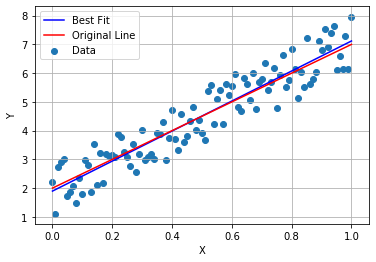

In [8]:
# Plotting it

plt.figure()
plt.grid(True)

plt.xlabel("X")
plt.ylabel("Y")

# Scatter points
plt.scatter(x0,y0,label="Data")

# Best fit line
yline = m_np*x0 + b_np

# Original line
yline2 = m*x0 + b

plt.plot(x0,yline,'blue',label="Best Fit")
plt.plot(x0,yline2,'red',label="Original Line")

plt.legend()

plt.show()

In [9]:
print("\nOriginal equation: y =",m,"x +",b)
print("Estimated equation: y =",m_np,"x +",b_np)


Original equation: y = 5 x + 2
Estimated equation: y = 5.222099865106903 x + 1.8966260489607496
